# Exploring the collate function

Before plugging `make_collate_fn` into a `DataLoader` and a Deepchecks `VisionData` object, let's see exactly what it produces for a single batch.

It takes a batch of raw Hugging Face dataset examples and returns a `BatchOutputFormat` with three things:
- `images`: a list of numpy arrays (H, W, C)
- `labels`: the ground-truth label for each image
- `predictions`: the model's predicted class probabilities for each image

In [1]:
from datasets import load_dataset
from transformers import pipeline

from validate import make_collate_fn

dataset = load_dataset("beans", split="validation")
label_names = dataset.features["labels"].names
label_names

/home/amalferiani/work/Udacity/MLops-course/cd15155-ml-ops-exercise/.venv/lib/python3.12/site-packages/deepchecks/core/serialization/dataframe/html.py:16: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



['angular_leaf_spot', 'bean_rust', 'healthy']

We use the base pretrained model here just to inspect the collate function — in `validate.py`, the pipeline comes from the `@dev` model loaded from the MLflow registry.

In [2]:
pipe = pipeline("image-classification", model="nateraw/vit-base-beans")
collate_fn = make_collate_fn(pipe, label_names)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [10]:
dataset[0]

{'image_file_path': '/home/albert/.cache/huggingface/datasets/downloads/extracted/ebfc96c159ae45a2d4ea69f80c256fd9699dd4695defa0c43f6c90f048632983/validation/angular_leaf_spot/angular_leaf_spot_val.0.jpg',
 'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x500>,
 'labels': 0}

In [6]:
batch = [dataset[i] for i in range(4)]
output = collate_fn(batch)

print("Number of images:", len(output["images"]))
print("Image shape:", output["images"][0].shape)
print("Labels:", output["labels"])
print("Predictions (probabilities per class):")
for p in output["predictions"]:
    print("  ", [round(x, 3) for x in p])

Number of images: 4
Image shape: (500, 500, 3)
Labels: [0, 0, 0, 0]
Predictions (probabilities per class):
   [0.942, 0.033, 0.025]
   [0.943, 0.036, 0.021]
   [0.783, 0.181, 0.037]
   [0.94, 0.028, 0.033]


Let's look at one image alongside its true label and the model's predicted label.

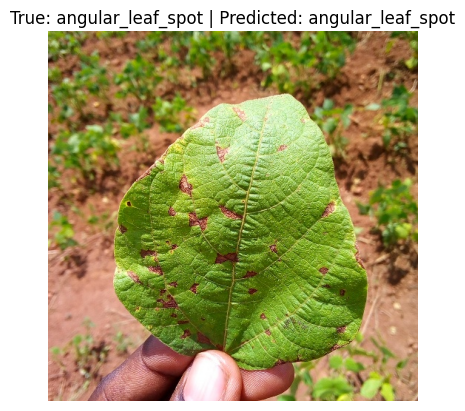

In [9]:
import matplotlib.pyplot as plt

idx = 0
true_label = label_names[output["labels"][idx]]
pred_label = label_names[output["predictions"][idx].index(max(output["predictions"][idx]))]

plt.imshow(output["images"][idx])
plt.title(f"True: {true_label} | Predicted: {pred_label}")
plt.axis("off")
plt.show()